# MWF protection 3/3/4 and simulation-tuned α

**Milestone:** CAL-01 calendar realism · **Decisions:** CTL-03 (simulation-tuned fractile), CAL-A1 order schedule (ADR 0114).

The base-case delivery cadence is **MWF** with lead time **LT = 1**. Trucks deliver Mon / Wed / Fri; the store orders on **Sun / Tue / Thu**. Under that calendar the protection interval is not a fixed scalar — it is **day-indexed**:

| Order day | Protection days |
|-----------|-----------------|
| Sunday    | 3 |
| Tuesday   | 3 |
| Thursday  | 4 |

Mon / Wed / Fri are **non-order** days (zero cases). This notebook walks through `sim/order_schedule.py`, the homogeneous-μ protection quantile helper, and `sim/alpha_tune.py` grid search that picks α by closed-loop episode profit rather than the textbook newsvendor fractile (ADR 0060, CTL-03=B).

## Setup

Install the editable package (`uv sync --extra notebooks --extra viz`; optional `--extra data` for Abdella parquet) and ensure `blueberries_voi` imports from `src/`. Epoch day 0 = Monday 2024-01-01 (ASN episode calendar).

The α grid below uses a **notebook-local** closed-loop helper that draws demand with `draw_demand` before `rust_bridge.day_step` (fixed-demand injection). `sim/alpha_tune.evaluate_alpha_episode_profit` still calls `episode.run_closed_loop_episode`, which omits that draw until T-121 F3 lands — same policy adapter, same profit objective.

In [1]:
from __future__ import annotations

from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np

from blueberries_voi.filter.belief import shelf_belief_from_cohorts_oracle
from blueberries_voi.model import Cohort, ModelParams, draw_demand
from blueberries_voi.rng import (
    STREAM_ALLOC,
    STREAM_ARRIVAL_SENSOR,
    STREAM_ARRIVAL_SHIP,
    STREAM_DEMAND,
    STREAM_SPOIL,
    spawn_rng,
)
from blueberries_voi.sim.alpha_tune import (
    DEFAULT_DESKTOP_ALPHAS,
    _ClosedLoopPolicyAdapter,
    protection_coverage_days,
)
from blueberries_voi.sim.bakeoff_damped_sw import protection_demand_quantile
from blueberries_voi.sim.case_round import case_round
from blueberries_voi.sim.day_tick import enqueue_pending_order, pop_arrival_units
from blueberries_voi.sim.open_loop import generate_arrival_age
from blueberries_voi.sim.order_schedule import DEFAULT_ORDER_SCHEDULE, OrderSchedule
from blueberries_voi.sim.profit import DEFAULT_PROFIT_COSTS, episode_profit
from blueberries_voi.sim.rust_bridge import day_step
from blueberries_voi.sim.shipments import smoke_cool_shipments
from blueberries_voi.sim.types_log import DayLog, EpisodeLog

EPOCH = date(2024, 1, 1)
WEEKDAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
params = ModelParams()
schedule = DEFAULT_ORDER_SCHEDULE

## Order schedule (`sim/order_schedule.py`)

`OrderSchedule` encodes delivery weekdays `{Mon, Wed, Fri}`, order weekdays `{Sun, Tue, Thu}`, and `lead_time_days = 1`. The protection length on any calendar day is

```
protection_days(day) = next_order_day(day) - day + lead_time_days
```

On order days this yields **3 / 3 / 4**; on Mon / Wed / Fri (delivery-only days) the next order is two days away plus LT, so protection is longer but `can_order` is false and policies return zero.

In [2]:
def weekday_name(day: int) -> str:
    return WEEKDAY_NAMES[(EPOCH + timedelta(days=day)).weekday()]


def example_day_for_weekday(target: int) -> int:
    """First epoch day whose weekday() equals target (0=Mon … 6=Sun)."""
    for day in range(7):
        if (EPOCH + timedelta(days=day)).weekday() == target:
            return day
    raise ValueError(target)


order_day_targets = {
    "Sun": 6,
    "Tue": 1,
    "Thu": 3,
}

protection_rows = []
for label, wd in order_day_targets.items():
    day = example_day_for_weekday(wd)
    prot = schedule.protection_days(day)
    protection_rows.append(
        {
            "order_day": label,
            "epoch_day": day,
            "weekday": weekday_name(day),
            "can_order": schedule.can_order(day),
            "next_order_day": schedule.next_order_day(day),
            "protection_days": prot,
        }
    )

protection_table = protection_rows
protection_table

[{'order_day': 'Sun',
  'epoch_day': 6,
  'weekday': 'Sun',
  'can_order': True,
  'next_order_day': 8,
  'protection_days': 3},
 {'order_day': 'Tue',
  'epoch_day': 1,
  'weekday': 'Tue',
  'can_order': True,
  'next_order_day': 3,
  'protection_days': 3},
 {'order_day': 'Thu',
  'epoch_day': 3,
  'weekday': 'Thu',
  'can_order': True,
  'next_order_day': 6,
  'protection_days': 4}]

In [3]:
non_order_targets = {"Mon": 0, "Wed": 2, "Fri": 4}
non_order_rows = []
for label, wd in non_order_targets.items():
    day = example_day_for_weekday(wd)
    non_order_rows.append(
        {
            "day": label,
            "epoch_day": day,
            "can_order": schedule.can_order(day),
            "protection_days": schedule.protection_days(day),
        }
    )

non_order_rows

[{'day': 'Mon', 'epoch_day': 0, 'can_order': False, 'protection_days': 2},
 {'day': 'Wed', 'epoch_day': 2, 'can_order': False, 'protection_days': 2},
 {'day': 'Fri', 'epoch_day': 4, 'can_order': False, 'protection_days': 3}]

## Protection demand quantile by weekday

`protection_demand_quantile(α, params, protection_days=n)` is the NB fractile of **n** i.i.d. daily demands with homogeneous μ (`nb_r` scaled by `n`). Under CAL-A3 / T-081 the **length** `n` varies by day via `OrderSchedule.protection_days(day)`; the mean stays `demand_mu` until CAL-B4 heterogeneous μ(day) lands.

In [4]:
alpha_plot = 0.9

quantile_rows = []
for wd in range(7):
    day = example_day_for_weekday(wd)
    prot = schedule.protection_days(day)
    d_star = protection_demand_quantile(alpha_plot, params, protection_days=prot)
    quantile_rows.append(
        {
            "weekday": WEEKDAY_NAMES[wd],
            "epoch_day": day,
            "can_order": schedule.can_order(day),
            "protection_days": prot,
            f"d* (α={alpha_plot})": round(d_star, 2),
            "coverage_fn": protection_coverage_days(day),
        }
    )

quantile_table = quantile_rows
quantile_table

[{'weekday': 'Mon',
  'epoch_day': 0,
  'can_order': False,
  'protection_days': 2,
  'd* (α=0.9)': 74.0,
  'coverage_fn': 2},
 {'weekday': 'Tue',
  'epoch_day': 1,
  'can_order': True,
  'protection_days': 3,
  'd* (α=0.9)': 107.0,
  'coverage_fn': 3},
 {'weekday': 'Wed',
  'epoch_day': 2,
  'can_order': False,
  'protection_days': 2,
  'd* (α=0.9)': 74.0,
  'coverage_fn': 2},
 {'weekday': 'Thu',
  'epoch_day': 3,
  'can_order': True,
  'protection_days': 4,
  'd* (α=0.9)': 140.0,
  'coverage_fn': 4},
 {'weekday': 'Fri',
  'epoch_day': 4,
  'can_order': False,
  'protection_days': 3,
  'd* (α=0.9)': 107.0,
  'coverage_fn': 3},
 {'weekday': 'Sat',
  'epoch_day': 5,
  'can_order': False,
  'protection_days': 2,
  'd* (α=0.9)': 74.0,
  'coverage_fn': 2},
 {'weekday': 'Sun',
  'epoch_day': 6,
  'can_order': True,
  'protection_days': 3,
  'd* (α=0.9)': 107.0,
  'coverage_fn': 3}]

### Homogeneous μ × varying protection (ADR 0116)

ADR **0116** assigns track ownership for CAL-01: controllers may use **day-varying protection length** with **homogeneous μ** (i.i.d. NB with fixed `demand_mu`) before FreshNet calendar demand (CAL-B3/B4) upgrades quantiles to heterogeneous daily means. The table above shows how `d*` moves with protection length even when μ is constant — Thu orders cover four demand days vs three on Sun/Tue.

Track B will land `draw_demand(..., day=)` and profile μ(day); until then CRN addressing stays `(root_seed, PHYSICS_RUN_ID, day, :demand)` and protection sums use scaled `nb_r * protection_days`.

### Rust `damped_sw_from_bank` still hardcodes 2-day protection

The PyO3 / Rust VOI hot path in `crates/voi_core/src/voi.rs` calls `protection_demand_quantile(alpha, params, 2)` inside `damped_sw_from_bank`, ignoring the episode `day` argument (`let _ = day`). Python `DampedSurvivalWeightedPolicy` and `alpha_tune` already use schedule-aware lengths (3/3/4). **Until the Rust kernel is updated**, browser / CRN VOI cells that route through `damped_sw_from_bank` still use the legacy **R+L = 2** scalar — a divergence worth flagging when comparing notebook figures to Studio autopilot runs.

## Simulation-tuned α vs textbook newsvendor (CTL-03)

ADR **0060** (CTL-03=B) rejects the single-period newsvendor fractile $c_s/(c_s+c_w)$ — leftover berries are sold later, not destroyed. The ladder instead **grid-searches** α on closed-loop `episode_profit` under shared CRN (`tune_alpha_grid` / `evaluate_alpha_episode_profit` in `sim/alpha_tune.py`).

For reference we still plot the textbook critical fractile using scaffold costs from `DEFAULT_PROFIT_COSTS` (uncalibrated, ADR 0104):

- understock $c_s$ = `stockout_penalty`, overstock $c_w$ = `waste_cost` → $\alpha^{\text{theory}} = c_s / (c_s + c_w)$
- lost-margin variant: `unit_margin / (unit_margin + waste_cost)`

In [5]:
costs = DEFAULT_PROFIT_COSTS
alpha_theory_penalty = costs.stockout_penalty / (costs.stockout_penalty + costs.waste_cost)
alpha_theory_margin = costs.unit_margin / (costs.unit_margin + costs.waste_cost)

print(f"Textbook (penalty / waste): {alpha_theory_penalty:.3f}")
print(f"Textbook (margin / waste):  {alpha_theory_margin:.3f}")
print(f"Desktop α grid: {DEFAULT_DESKTOP_ALPHAS}")

Textbook (penalty / waste): 0.667
Textbook (margin / waste):  0.571
Desktop α grid: (0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95)


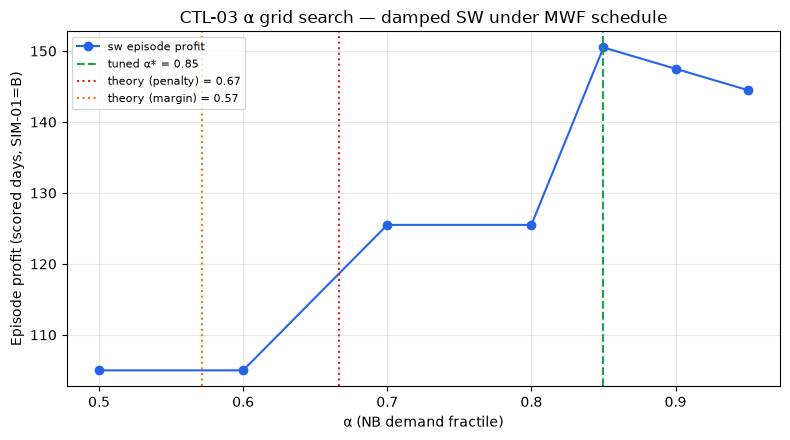

[(0.5, 105.0),
 (0.6, 105.0),
 (0.7, 125.5),
 (0.8, 125.5),
 (0.85, 150.5),
 (0.9, 147.5),
 (0.95, 144.5)]

In [6]:
ORACLE_TAU_GRID = (0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0)
SMOKE_SHIPS = smoke_cool_shipments()
N_BURN, N_SCORE = 2, 5  # tiny for notebook; production tuning uses longer horizons


def notebook_evaluate_alpha_profit(
    arm_id: str,
    alpha: float,
    root_seed: int,
    *,
    params: ModelParams = params,
    costs=DEFAULT_PROFIT_COSTS,
    n_burn: int = N_BURN,
    n_score: int = N_SCORE,
) -> float:
    """Mirror alpha_tune scoring with draw_demand + rust day_step injection."""
    policy = _ClosedLoopPolicyAdapter(arm_id, alpha, params, schedule=schedule)
    cohorts: list[Cohort] = []
    pending: dict[int, int] = {}
    next_lot = 1
    log = EpisodeLog(n_burn=n_burn, n_score=n_score)
    horizon = n_burn + n_score
    run_id = "alpha-tune-nb"

    for day in range(horizon):
        belief = shelf_belief_from_cohorts_oracle(
            cohorts, empty_tau_grid=ORACLE_TAU_GRID
        )
        raw_qty = policy.order(day, belief, pending_orders=dict(pending))
        order_units = case_round(raw_qty, params.case_size)
        if not schedule.can_order(day):
            order_units = 0
        enqueue_pending_order(pending, day, schedule.lead_time_days, order_units)

        arrival_units = pop_arrival_units(pending, day)
        delivery = None
        if arrival_units > 0:
            rng_ship = spawn_rng(
                root_seed, run_id=run_id, day=day, stream=STREAM_ARRIVAL_SHIP
            )
            rng_sensor = spawn_rng(
                root_seed, run_id=run_id, day=day, stream=STREAM_ARRIVAL_SENSOR
            )
            tau_in = generate_arrival_age(
                rng_ship, rng_sensor, SMOKE_SHIPS, params
            )
            delivery = Cohort(n=arrival_units, tau=tau_in, lot_id=next_lot)
            next_lot += 1

        rng_d = spawn_rng(root_seed, run_id=run_id, day=day, stream=STREAM_DEMAND)
        rng_a = spawn_rng(root_seed, run_id=run_id, day=day, stream=STREAM_ALLOC)
        rng_s = spawn_rng(root_seed, run_id=run_id, day=day, stream=STREAM_SPOIL)
        demand = draw_demand(rng_d, params, day=day)
        result = day_step(
            cohorts,
            params=params,
            demand=demand,
            delivery=delivery,
            rng_alloc=rng_a,
            rng_spoil=rng_s,
            day=day,
        )
        cohorts = result.cohorts
        log.days.append(
            DayLog(
                day=day,
                lots=[],
                sales_total=result.sales_total,
                waste_total=result.waste_total,
                arrivals=arrival_units,
                order_qty=order_units,
                demand=result.demand,
                L=len(cohorts),
            )
        )
    return float(episode_profit(log, costs))


ROOT_SEED = 42
ARM = "sw"  # damped survival-weighted ladder arm

profits = [
    notebook_evaluate_alpha_profit(ARM, float(a), ROOT_SEED, costs=costs)
    for a in DEFAULT_DESKTOP_ALPHAS
]
best_alpha = DEFAULT_DESKTOP_ALPHAS[int(np.argmax(profits))]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(DEFAULT_DESKTOP_ALPHAS, profits, "o-", color="#2563eb", label=f"{ARM} episode profit")
ax.axvline(best_alpha, color="#16a34a", linestyle="--", label=f"tuned α* = {best_alpha:.2f}")
ax.axvline(alpha_theory_penalty, color="#dc2626", linestyle=":", label=f"theory (penalty) = {alpha_theory_penalty:.2f}")
ax.axvline(alpha_theory_margin, color="#f97316", linestyle=":", label=f"theory (margin) = {alpha_theory_margin:.2f}")
ax.set_xlabel("α (NB demand fractile)")
ax.set_ylabel("Episode profit (scored days, SIM-01=B)")
ax.set_title("CTL-03 α grid search — damped SW under MWF schedule")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

list(zip(DEFAULT_DESKTOP_ALPHAS, [round(p, 2) for p in profits]))

## Weekday quantile chart

Bar chart of protection length and $d^*(\alpha)$ by weekday (α = 0.9). Order days are highlighted.

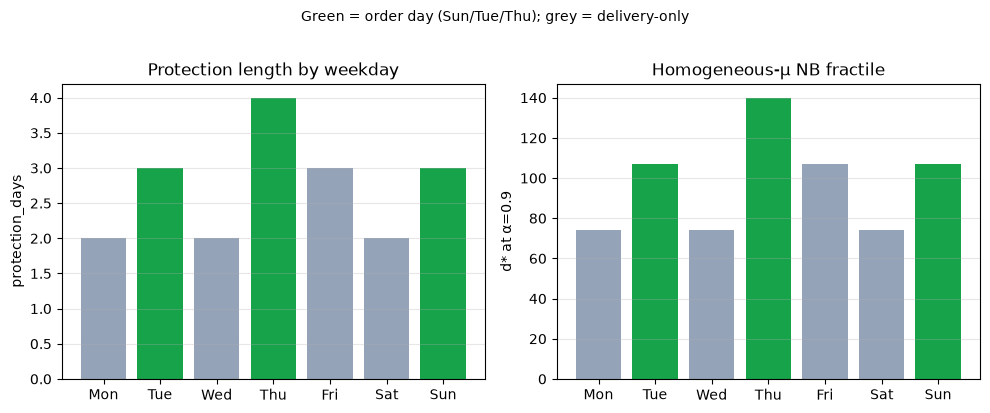

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = np.arange(7)
quantile_by_wd = {r["weekday"]: r for r in quantile_rows}
prot_vals = [quantile_by_wd[w]["protection_days"] for w in WEEKDAY_NAMES]
d_star_vals = [quantile_by_wd[w][f"d* (α={alpha_plot})"] for w in WEEKDAY_NAMES]
colors = ["#16a34a" if quantile_by_wd[w]["can_order"] else "#94a3b8" for w in WEEKDAY_NAMES]

axes[0].bar(x, prot_vals, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(WEEKDAY_NAMES)
axes[0].set_ylabel("protection_days")
axes[0].set_title("Protection length by weekday")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x, d_star_vals, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(WEEKDAY_NAMES)
axes[1].set_ylabel(f"d* at α={alpha_plot}")
axes[1].set_title("Homogeneous-μ NB fractile")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Green = order day (Sun/Tue/Thu); grey = delivery-only", fontsize=10, y=1.02)
fig.tight_layout()
plt.show()

## Order calendar heatmap

Two-week strip of the epoch calendar: order gate, delivery day, and protection length. Values are read directly from `OrderSchedule` — the same source the web Demand UI mirrors via `order_weekdays` + `lead_time_days`.

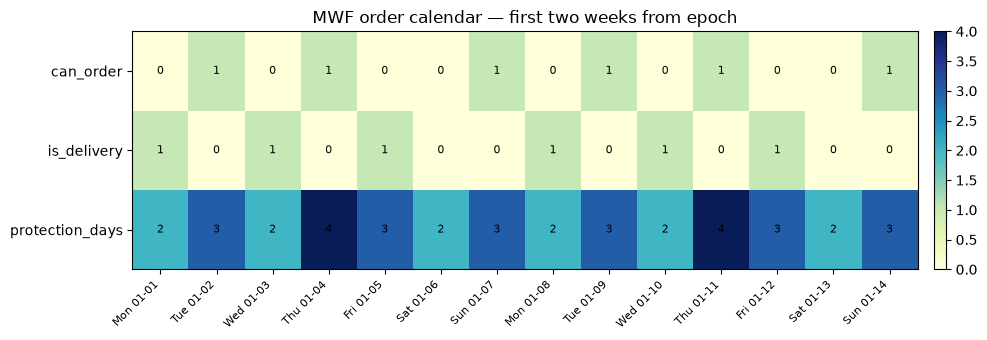

[{'day': 0,
  'label': 'Mon 01-01',
  'can_order': 0,
  'is_delivery': 1,
  'protection_days': 2},
 {'day': 1,
  'label': 'Tue 01-02',
  'can_order': 1,
  'is_delivery': 0,
  'protection_days': 3},
 {'day': 2,
  'label': 'Wed 01-03',
  'can_order': 0,
  'is_delivery': 1,
  'protection_days': 2},
 {'day': 3,
  'label': 'Thu 01-04',
  'can_order': 1,
  'is_delivery': 0,
  'protection_days': 4},
 {'day': 4,
  'label': 'Fri 01-05',
  'can_order': 0,
  'is_delivery': 1,
  'protection_days': 3},
 {'day': 5,
  'label': 'Sat 01-06',
  'can_order': 0,
  'is_delivery': 0,
  'protection_days': 2},
 {'day': 6,
  'label': 'Sun 01-07',
  'can_order': 1,
  'is_delivery': 0,
  'protection_days': 3},
 {'day': 7,
  'label': 'Mon 01-08',
  'can_order': 0,
  'is_delivery': 1,
  'protection_days': 2},
 {'day': 8,
  'label': 'Tue 01-09',
  'can_order': 1,
  'is_delivery': 0,
  'protection_days': 3},
 {'day': 9,
  'label': 'Wed 01-10',
  'can_order': 0,
  'is_delivery': 1,
  'protection_days': 2},
 {'day': 1

In [8]:
horizon = 14
rows = []
for day in range(horizon):
    wd = (EPOCH + timedelta(days=day)).weekday()
    rows.append(
        {
            "day": day,
            "label": f"{WEEKDAY_NAMES[wd]} {EPOCH + timedelta(days=day):%m-%d}",
            "can_order": int(schedule.can_order(day)),
            "is_delivery": int(wd in schedule.delivery_weekdays),
            "protection_days": schedule.protection_days(day),
        }
    )

calendar = rows
heat_labels = [r["label"] for r in calendar]
heat = np.array(
    [[r["can_order"], r["is_delivery"], r["protection_days"]] for r in calendar]
)

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(heat.T, aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(3))
ax.set_yticklabels(["can_order", "is_delivery", "protection_days"])
ax.set_xticks(range(horizon))
ax.set_xticklabels(heat_labels, rotation=45, ha="right", fontsize=8)
ax.set_title("MWF order calendar — first two weeks from epoch")

for i in range(3):
    for j in range(horizon):
        val = heat[j, i]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=8, color="black")

fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
fig.tight_layout()
plt.show()

calendar

## Takeaways

1. **3/3/4** protection on Sun / Tue / Thu order days is a consequence of `next_order_day + LT`, not a hand-tuned table.
2. Quantiles use **homogeneous μ** with day-varying `protection_days` until CAL-B4 heterogeneous demand.
3. **CTL-03** tuned α* from simulation generally differs from textbook $c_s/(c_s+c_w)$ on scaffold costs.
4. **Rust VOI** `damped_sw_from_bank` still uses **2-day** protection — compare Python notebook results to Studio with that caveat.

Next notebook in the exploration chain: calendar demand μ(day) from FreshNet (CAL-B3/B4) and retuned α gates (T-083).